In [64]:
import pandas as pd
import numpy as np
book_small = pd.read_json('goodreads_books.json', lines=True, nrows=10000)
book_small = book_small[book_small["description"].notna() & (book_small["description"].str.strip() != "")]
book_small.shape

(8250, 29)

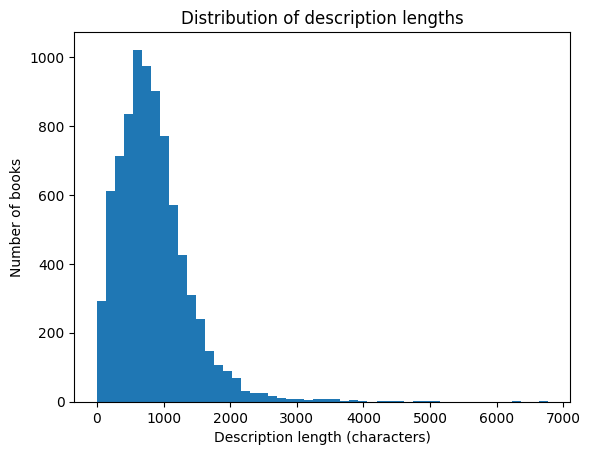

In [69]:
import matplotlib.pyplot as plt

# Length of each description (in characters)
book_small["desc_length"] = book_small["description"].fillna("").str.len()

# Plot histogram
plt.figure()
plt.hist(book_small["desc_length"], bins=50)
plt.xlabel("Description length (characters)")
plt.ylabel("Number of books")
plt.title("Distribution of description lengths")
plt.show()

In [53]:
book_small.columns

Index(['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code',
       'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin',
       'similar_books', 'description', 'format', 'link', 'authors',
       'publisher', 'num_pages', 'publication_day', 'isbn13',
       'publication_month', 'edition_information', 'publication_year', 'url',
       'image_url', 'book_id', 'ratings_count', 'work_id', 'title',
       'title_without_series'],
      dtype='object')

In [52]:
book_small.iloc[[7957,3812,8249,5119,6731,7547,2990]]

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
7957,0316324108,33,[],US,eng,"[{'count': '5056', 'name': 'to-read'}, {'count...",,false,4.34,B000QRIGLC,...,11,,2013,https://www.goodreads.com/book/show/17968690-l...,https://images.gr-assets.com/books/1380494242m...,17968690,211,1623890,Lone Survivor: The Eyewitness Account of Opera...,Lone Survivor: The Eyewitness Account of Opera...
3812,0385515057,14,[],US,,"[{'count': '35', 'name': 'to-read'}, {'count':...",,false,3.36,B000PDZFHK,...,1,,2006,https://www.goodreads.com/book/show/1674383.St...,https://s.gr-assets.com/assets/nophoto/book/11...,1674383,47,132839,Strapped: Why America's 20- and 30-Somethings ...,Strapped: Why America's 20- and 30-Somethings ...
8249,1507204442,1,[1044264],US,eng,"[{'count': '11', 'name': 'to-read'}, {'count':...",,true,4.25,,...,4,,2017,https://www.goodreads.com/book/show/34324918-a...,https://images.gr-assets.com/books/1489326153m...,34324918,3,55387759,A Kiss in the Morning Mist,A Kiss in the Morning Mist
5119,1440631697,26,[153122],US,,"[{'count': '14219', 'name': 'to-read'}, {'coun...",,true,4.04,,...,,,,https://www.goodreads.com/book/show/8582584-fo...,https://s.gr-assets.com/assets/nophoto/book/11...,8582584,211,855288,"Fool Moon (The Dresden Files, #2)","Fool Moon (The Dresden Files, #2)"
6731,4770026102,32,[],US,eng,"[{'count': '1235', 'name': 'to-read'}, {'count...",,false,4.01,B00DC9A5I8,...,1,,2001,https://www.goodreads.com/book/show/194739.Blu...,https://s.gr-assets.com/assets/nophoto/book/11...,194739,270,297542,Blue Bamboo: Japanese Tales of Fantasy,Blue Bamboo: Japanese Tales of Fantasy
7547,1925267318,14,[],US,,"[{'count': '69', 'name': 'to-read'}, {'count':...",,false,4.18,,...,,,2016,https://www.goodreads.com/book/show/31194200-i...,https://images.gr-assets.com/books/1469169855m...,31194200,69,51840217,"In Sickness, in Health ... and in Jail: What H...","In Sickness, in Health ... and in Jail: What H..."
2990,143914477X,2,[552208],US,,"[{'count': '10997', 'name': 'to-read'}, {'coun...",,true,3.97,,...,3,,2014,https://www.goodreads.com/book/show/18870128-t...,https://images.gr-assets.com/books/1418615428m...,18870128,15,6887879,Time and Again,Time and Again


In [8]:
descriptions5 = book_small.iloc[[7957,3812,8249,5119,6731,7547,2990]][['book_id','description']]

In [9]:
descriptions5.iloc[[0]]

,book_id,description
7957,17968690,Four US Navy SEALS departed one clear night in...


## extract labelled information

In [10]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

description = descriptions5.iloc[0]

# Feature: ambiance (multi-label possible)
result = classifier(
    description,
    candidate_labels=["romantic", "dark", "adventure", "comedy", "thriller", "historical"],
    multi_label=True
)
# → {"labels": ["romantique", "historique", "aventure"], "scores": [0.91, 0.87, 0.72, ...]}

# Feature: public cible (single-label)
result2 = classifier(
    description,
    candidate_labels=["children", "young adult", "adult"],
    multi_label=False
)

ModuleNotFoundError: No module named 'transformers'

In [56]:
def extract_labels(result, threshold_high=0.80, threshold_low=0.60):
    high_confidence = [
        label for label, score
        in zip(result["labels"], result["scores"])
        if score >= threshold_high
    ]
    
    if high_confidence:
        return high_confidence
    
    best_label = result["labels"][0]
    best_score = result["scores"][0]
    
    if best_score >= threshold_low:
        return [best_label]
    
    return []

In [58]:
print(result)
ambiance   = extract_labels(result) 
public     = extract_labels(result2)  
print(ambiance)
print(public)

{'sequence': "Four US Navy SEALS departed one clear night in early July, 2005 for the mountainous Afghanistan-Pakistan border for a reconnaissance mission. Their task was to document the activity of an al Qaeda leader rumored to be very close to Bin Laden with a small army in a Taliban stronghold. Five days later, only one of those Navy SEALS made it out alive.\nThis is the story of the only survivor of Operation Redwing, SEAL fire team leader Marcus Luttrell, and the extraordinary firefight that led to the largest loss of life in American Navy SEAL history. His squadmates fought valiantly beside him until he was the only one left alive, blasted by an RPG into a place where his pursuers could not find him. Over the next four days, terribly injured and presumed dead, Luttrell crawled for miles through the mountains and was taken in by sympathetic villagers who risked their lives to keep him safe from surrounding Taliban warriors.\nA born and raised Texan, Marcus Luttrell takes us from t

## extract structured prompt (city, period,...) Mistral

In [98]:
description = descriptions5.iloc[0]

In [99]:
from transformers import pipeline
import json

generator = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.2",
    # device_map="auto",
    max_new_tokens=512
)

SYSTEM_PROMPT = """You are an expert in literary analysis.
Reply ONLY with a valid JSON object, no markdown, no explanation."""

USER_PROMPT = """Analyze this book description and extract the following information.
If a piece of information is absent or uncertain, use null.

Description: {description}

Reply with exactly this JSON format:
{{
  # "location": {{
  #   "city": string | null,
  #   "country": string | null,
  #   "world": "real" | "fictional" | "mixed"
  # }},
  "period": {{
    "century": string | null,
    "decade": string | null,
    "era": string | null
  }}
  # "hobbies": [string],
  # "main_characters": [string],
  # "mood": [string],
  # "target_audience": "children" | "young adult" | "adult" | "all ages",
  # "themes": [string],
  # "original_language": string | null
}}"""

def extract_features(description: str) -> dict:
    prompt = f"[INST] {SYSTEM_PROMPT}\n\n{USER_PROMPT.format(description=description)} [/INST]"
    
    output = generator(prompt, do_sample=False, temperature=None)[0]["generated_text"]
    
    generated = output[len(prompt):]
    
    json_str = generated.strip()
    if "```" in json_str:
        json_str = json_str.split("```")[1].replace("json", "").strip()
    
    return json.loads(json_str)

ModuleNotFoundError: No module named 'transformers'

In [ ]:
descriptions5.iloc[0]

In [100]:
from huggingface_hub import InferenceClient
import json

client = InferenceClient(
    model="mistralai/Mistral-7B-Instruct-v0.2",
    token="hf_your_token"  # free tier available on hf.co
)

SYSTEM_PROMPT = """You are an expert in literary analysis.
Reply ONLY with a valid JSON object, no markdown, no explanation."""

USER_PROMPT = """Analyze this book description and extract the following information.
If a piece of information is absent or uncertain, use null.

Description: {description}

Reply with exactly this JSON format:
{{
  "location": {{
    "city": string | null,
    "country": string | null,
    "world": "real" | "fictional" | "mixed"
  }},
  "period": {{
    "century": string | null,
    "decade": string | null,
    "era": string | null
  }},
  "hobbies": [string],
  "main_characters": [string],
  "mood": [string],
  "target_audience": "children" | "young adult" | "adult" | "all ages",
  "themes": [string],
  "original_language": string | null
}}"""

def extract_features(description: str) -> dict:
    prompt = f"[INST] {SYSTEM_PROMPT}\n\n{USER_PROMPT.format(description=description)} [/INST]"
    
    response = client.text_generation(prompt, max_new_tokens=512, do_sample=False)
    
    json_str = response.strip()
    if "```" in json_str:
        json_str = json_str.split("```")[1].replace("json", "").strip()
    
    return json.loads(json_str)

In [101]:
result = extract_features(description)

ValueError: Model mistralai/Mistral-7B-Instruct-v0.2 is not supported for task text-generation and provider featherless-ai. Supported task: conversational.

## chat GPT example

In [10]:
# schema
from pydantic import BaseModel
from typing import List, Optional, Literal

class Location(BaseModel):
    city: Optional[str] = None
    country: Optional[str] = None
    world: Literal["real", "fictional", "mixed"]

class Period(BaseModel):
    century: Optional[str] = None
    decade: Optional[str] = None
    era: Optional[str] = None

class BookMetadata(BaseModel):
    location: Location
    period: Period
    hobbies: List[str]
    main_characters: List[str]
    mood: List[str]
    target_audience: Literal["children", "young adult", "adult", "all ages"]
    themes: List[str]
    original_language: Optional[str] = None

In [11]:
SYSTEM_PROMPT = """
You extract structured metadata from book descriptions.

Return only valid JSON matching this schema:

{
  "location": {
    "city": string | null,
    "country": string | null,
    "world": "real" | "fictional" | "mixed"
  },
  "period": {
    "century": string | null,
    "decade": string | null,
    "era": string | null
  },
  "hobbies": [string],
  "main_characters": [string],
  "mood": [string],
  "target_audience": "children" | "young adult" | "adult" | "all ages",
  "themes": [string],
  "original_language": string | null
}

Rules:
- Use null when unknown.
- Do not invent details not supported by the text.
- "world" is:
  - "real" if the setting is the real world
  - "fictional" if the setting is invented
  - "mixed" if both are present
- "period" should reflect when the story takes place, not publication date.
- "mood" should be short labels like "dark", "hopeful", "romantic", "tense".
- "themes" should be broad literary themes like "war", "friendship", "identity", "survival".
- "target_audience" should be inferred from the description.
"""

In [12]:
import json
from openai import OpenAI

client = OpenAI()

def extract_book_metadata(description: str):
    response = client.chat.completions.create(
        model="gpt-5.1",  # example
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": description}
        ],
        temperature=0
    )

    content = response.choices[0].message.content
    data = json.loads(content)
    return BookMetadata(**data).model_dump()

ModuleNotFoundError: No module named 'openai'

In [ ]:
description = descriptions5.iloc[0]

metadata = extract_book_metadata(description)
print(metadata)

## extract structured prompt (city, period,...) Langchain example

In [11]:
from dotenv import load_dotenv
dot_env_loaded = load_dotenv()
dot_env_loaded

True

In [93]:
import json
import re
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate

model = init_chat_model("google_genai:gemini-2.5-flash")

schema = """{
  # "location": {
  #   "city": null,
  #   "country": null,
  #   "world": "real",
  #   "geography_type": null,
  #   "environment_features": []
  # },
  "period": {
    "century": null,
    "decade": null,
    "era": null,
    "historical_event_context": null,
    "season": null
  }
  # "genre": null,
  # "subgenres": [],
  # "format": null,
  # "story_count": null,
  # "timeline_structure": null,
  # "main_characters": [],
  # "protagonist_profession": null,
  # "protagonist_traits": [],
  # "relationship_types": [],
  # "conflict": {
  #   "primary_conflict_type": null,
  #   "stakes_level": null,
  #   "violence_level": null
  # },
  # "supernatural": {
  #   "has_supernatural": false,
  #   "magic_system": null,
  #   "supernatural_entities": [],
  #   "mythological_influences": []
  # },
  # "tone": [],
  # "mood": [],
  # "themes": [],
  # "moral_themes": [],
  # "psychological_themes": [],
  # "social_themes": [],
  # "hobbies": [],
  # "target_audience": "adult",
  # "content_warnings": [],
  # "original_language": null,
  # "cultural_origin": null,
  # "literary_tradition": null,
  # "awards": []
}"""

# schema = """{
#   "location": {
#     "city": null,
#     "country": null,
#     "world": "real"
#   },
#   "period": {
#     "century": null,
#     "decade": null,
#     "era": null
#   },
#   "hobbies": [],
#   "main_characters": [],
#   "mood": [],
#   "target_audience": "adult",
#   "themes": [],
#   "original_language": null
# }"""

prompt = ChatPromptTemplate.from_template("""
You extract metadata from book descriptions.

Return ONLY valid JSON.
Do not add explanations.
Do not use markdown code fences.

Use this schema:
{schema}

Rules:
- Use null when unknown
- Do not invent unsupported details
- "world" must be one of: "real", "fictional", "mixed"
- "target_audience" must be one of: "children", "young adult", "adult", "all ages"

Description:
{description}
""")


def extract_json_block(text):
    # Remove markdown fences if present
    text = text.strip()
    text = re.sub(r"^```json", "", text)
    text = re.sub(r"^```", "", text)
    text = re.sub(r"```$", "", text)
    text = text.strip()

    # Try full text first
    try:
        return json.loads(text)
    except:
        pass

    # Try to extract the first JSON object
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        candidate = match.group(0)
        return json.loads(candidate)

    raise ValueError("No valid JSON object found")


def extract_metadata(description, max_chars=1500):
    description = description.strip()[:max_chars]
    formatted_prompt = prompt.invoke({
        "schema": schema,
        "description": description
    })

    response = model.invoke(formatted_prompt)
    text = response.content

    # print("RAW MODEL OUTPUT:\n", text)   # useful for debugging

    try:
        return extract_json_block(text)
    except Exception as e:
        print("Parsing error:", e)
        return None

In [37]:
description = descriptions5.iloc[4]
description

book_id                                                  8582584
description    Business has been slow. Okay, business has bee...
Name: 5119, dtype: object

In [50]:
import pandas as pd
import os

def book_id_not_in_csv(book_id, csv_filename="structured_features.csv"):
    if not os.path.exists(csv_filename):
        return True

    df = pd.read_csv(csv_filename)

    return str(book_id) not in df["book_id"].astype(str).values

In [71]:
description = descriptions5.iloc[4]
type(description['book_id'])
book_id_not_in_csv(description['book_id'])
descriptions5 = book_small.iloc[0:5][['book_id','description']]
descriptions5['description']

1    Anita Diamant's international bestseller "The ...
2    Omnibus book club edition containing the Ladie...
3    Addie Downs and Valerie Adler were eight when ...
5    Relates in vigorous prose the tale of Aeneas, ...
7    To Kara's astonishment, she discovers that a p...
Name: description, dtype: object

In [40]:
description = descriptions5.iloc[0]
metadata = if book_id_not_in_csv(description['book_id']): extract_metadata(description)
print(metadata)

RAW MODEL OUTPUT:
 {
  "location": {
    "city": null,
    "country": null,
    "world": "real",
    "geography_type": null,
    "environment_features": []
  },
  "period": {
    "century": null,
    "decade": null,
    "era": null,
    "historical_event_context": null,
    "season": null
  },
  "genre": "Short Story Collection",
  "subgenres": [],
  "format": "Short Story Collection",
  "story_count": 7,
  "timeline_structure": null,
  "main_characters": [],
  "protagonist_profession": null,
  "protagonist_traits": [],
  "relationship_types": [],
  "conflict": {
    "primary_conflict_type": null,
    "stakes_level": null,
    "violence_level": null
  },
  "supernatural": {
    "has_supernatural": false,
    "magic_system": null,
    "supernatural_entities": [],
    "mythological_influences": []
  },
  "tone": [],
  "mood": [],
  "themes": [],
  "moral_themes": [],
  "psychological_themes": [],
  "social_themes": [],
  "hobbies": [],
  "target_audience": "adult",
  "content_warnings": 

In [72]:
import csv

def flatten_dict(d, parent_key="", sep="."):
    """
    Recursively flattens a nested dictionary.
    Example:
      {"location": {"city": "Tokyo"}} 
      → {"location.city": "Tokyo"}
    """
    items = {}
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k

        if isinstance(v, dict):
            items.update(flatten_dict(v, new_key, sep=sep))
        elif isinstance(v, list):
            items[new_key] = ", ".join(map(str, v))
        else:
            items[new_key] = v
    return items


import csv
import os

def write_book_info_to_csv(data_list, book_id, csv_filename):
    """
    Appends book data to a CSV file.
    Adds book_id as the first column.
    """

    # Flatten all dictionaries first
    flat_data = [flatten_dict(d) for d in data_list]

    # Add book_id to each row
    for entry in flat_data:
        entry["book_id"] = book_id

    # Collect all possible column names
    all_keys = set()
    for entry in flat_data:
        all_keys.update(entry.keys())

    # Ensure book_id is first column
    all_keys = sorted(all_keys - {"book_id"})
    fieldnames = ["book_id"] + all_keys

    # Check if file already exists
    file_exists = os.path.isfile(csv_filename)

    # Open in append mode
    with open(csv_filename, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # Write header only if file does not exist
        if not file_exists:
            writer.writeheader()

        writer.writerows(flat_data)

    print(f"book {book_id} appended to {csv_filename}")


In [96]:
descriptions5 = book_small.iloc[6:46][['book_id','description']]
descriptions5.shape

(40, 2)

In [97]:
for _, description in descriptions5.iterrows():
    # description = descriptions5.iloc[4]
    print(description['book_id'])
    if(book_id_not_in_csv(description['book_id'])):
        metadata = extract_metadata(description['description'])
        write_book_info_to_csv([metadata], description['book_id'], 'structured_features.csv')
    else:
        print('book already in csv')
    print(f"book not in csv {book_id_not_in_csv(description['book_id'])}")

287149
book already in csv
book not in csv False
6066814
book 6066814 appended to structured_features.csv
book not in csv False
89371
book 89371 appended to structured_features.csv
book not in csv False
28575155
book 28575155 appended to structured_features.csv
book not in csv False
89375
book 89375 appended to structured_features.csv
book not in csv False
89376
book 89376 appended to structured_features.csv
book not in csv False
89377
book 89377 appended to structured_features.csv
book not in csv False
89378
book 89378 appended to structured_features.csv
book not in csv False
2008911
book 2008911 appended to structured_features.csv
book not in csv False
2008910
book 2008910 appended to structured_features.csv
book not in csv False
7203847
book 7203847 appended to structured_features.csv
book not in csv False
6158967
book 6158967 appended to structured_features.csv
book not in csv False
12182387
book 12182387 appended to structured_features.csv
book not in csv False
287142
book 287142 